# Pipeline Làm Sạch Dữ Liệu & Tính AQI — 12 Trạm Quan Trắc

Notebook này xây dựng pipeline xử lý dữ liệu quan trắc không khí Bắc Kinh giai đoạn 2013–2017.

Quy trình gồm: nạp dữ liệu thô, kiểm tra chất lượng, chuẩn hóa chuỗi thời gian theo giờ, xử lý giá trị thiếu, tính AQI theo giờ, kiểm tra kết quả và xuất dữ liệu sạch cho EDA/modeling.


## 0. Khởi tạo pipeline

Thiết lập thư mục dữ liệu, tên file đầu ra và danh sách các pollutant, yếu tố khí tượng sẽ được sử dụng trong các bước tiếp theo.


In [21]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

DATA_DIR   = "data"
OUT_FILE   = "data_cleaned_all_stations.parquet"
PALETTE    = sns.color_palette("tab20", 12)
POLLUTANTS = ["PM2.5","PM10","SO2","NO2","CO","O3"]
METEO      = ["TEMP","PRES","DEWP","RAIN","WSPM"]
NUM_COLS   = POLLUTANTS + METEO
print("Thư mục dữ liệu:", DATA_DIR)
print("Trạm:", sorted(os.listdir(DATA_DIR)))


Thư mục dữ liệu: data
Trạm: ['Aotizhongxin', 'Changqing', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongchanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


## 0.1. Nạp và kiểm tra dữ liệu thô

Đọc file `data.csv` trong từng thư mục trạm, bổ sung tên trạm nếu dữ liệu chưa có cột `station`, sau đó gộp thành `df_all_raw`.

Các kiểm tra ban đầu gồm:
- Số lượng trạm và số dòng của từng trạm.
- Tổng số dòng và số cột.
- Danh sách cột có trong dữ liệu.

Chênh lệch số dòng giữa các trạm giúp phát hiện dữ liệu thiếu bất thường trước khi làm sạch.


In [22]:
stations_raw = {}
for folder in sorted(os.listdir(DATA_DIR)):
    fp = os.path.join(DATA_DIR, folder, "data.csv")
    if os.path.isfile(fp):
        df = pd.read_csv(fp, low_memory=False)
        if "station" not in df.columns:
            df["station"] = folder
        stations_raw[folder] = df

df_all_raw = pd.concat(stations_raw.values(), ignore_index=True)
row_counts_raw = {st: len(df) for st, df in stations_raw.items()}

print(f"Số trạm: {len(stations_raw)}")
for st, n in sorted(row_counts_raw.items()):
    print(f"  {st:20s}: {n:>6,} dòng")
print(f"Tổng: {df_all_raw.shape[0]:,} dòng | {df_all_raw.shape[1]} cột")
print("Cột:", df_all_raw.columns.tolist())


Số trạm: 12
  Aotizhongxin        : 35,064 dòng
  Changqing           : 35,064 dòng
  Dingling            : 35,064 dòng
  Dongsi              : 35,064 dòng
  Guanyuan            : 35,064 dòng
  Gucheng             : 35,064 dòng
  Huairou             : 35,064 dòng
  Nongchanguan        : 35,064 dòng
  Shunyi              : 35,064 dòng
  Tiantan             : 35,064 dòng
  Wanliu              : 35,064 dòng
  Wanshouxigong       : 35,064 dòng
Tổng: 420,768 dòng | 18 cột
Cột: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']


## 0.2. Khảo sát giá trị thiếu trong dữ liệu thô

Tính tỷ lệ thiếu của các pollutant theo từng trạm và tìm khoảng thiếu liên tục dài nhất của PM2.5.

Khoảng thiếu ngắn có thể xử lý bằng nội suy thời gian, trong khi khoảng thiếu dài cần dùng thống kê theo mùa/giờ hoặc median của trạm. Heatmap và biểu đồ khoảng thiếu giúp lựa chọn chiến lược imputation phù hợp trước khi biến đổi dữ liệu.


% Thiếu:
                PM2.5  PM10   SO2   NO2    CO    O3
Aotizhongxin    2.64  2.05  2.67  2.92  5.07  4.90
Changqing       2.21  1.66  1.79  1.90  4.34  1.72
Dingling        2.22  1.87  2.08  3.52  5.74  3.46
Dongsi          2.14  1.58  1.89  4.57  9.12  1.89
Guanyuan        1.76  1.22  1.35  1.88  5.00  3.35
Gucheng         1.84  1.09  1.45  1.91  4.00  2.08
Huairou         2.72  2.22  2.79  4.67  4.06  3.28
Nongchanguan    1.79  1.25  1.27  1.97  3.44  1.44
Shunyi          2.60  1.56  3.70  3.89  6.21  4.25
Tiantan         1.93  1.70  3.19  2.12  3.21  2.40
Wanliu          1.09  0.81  1.64  3.05  5.17  6.01
Wanshouxigong   1.98  1.38  1.91  2.15  3.70  3.07

Khoảng trống dài nhất PM2.5 (giờ):
Aotizhongxin     343
Huairou          208
Shunyi           197
Changqing        167
Dingling          72
Guanyuan          71
Dongsi            58
Nongchanguan      56
Gucheng           54
Wanshouxigong     43
Tiantan           24
Wanliu            23


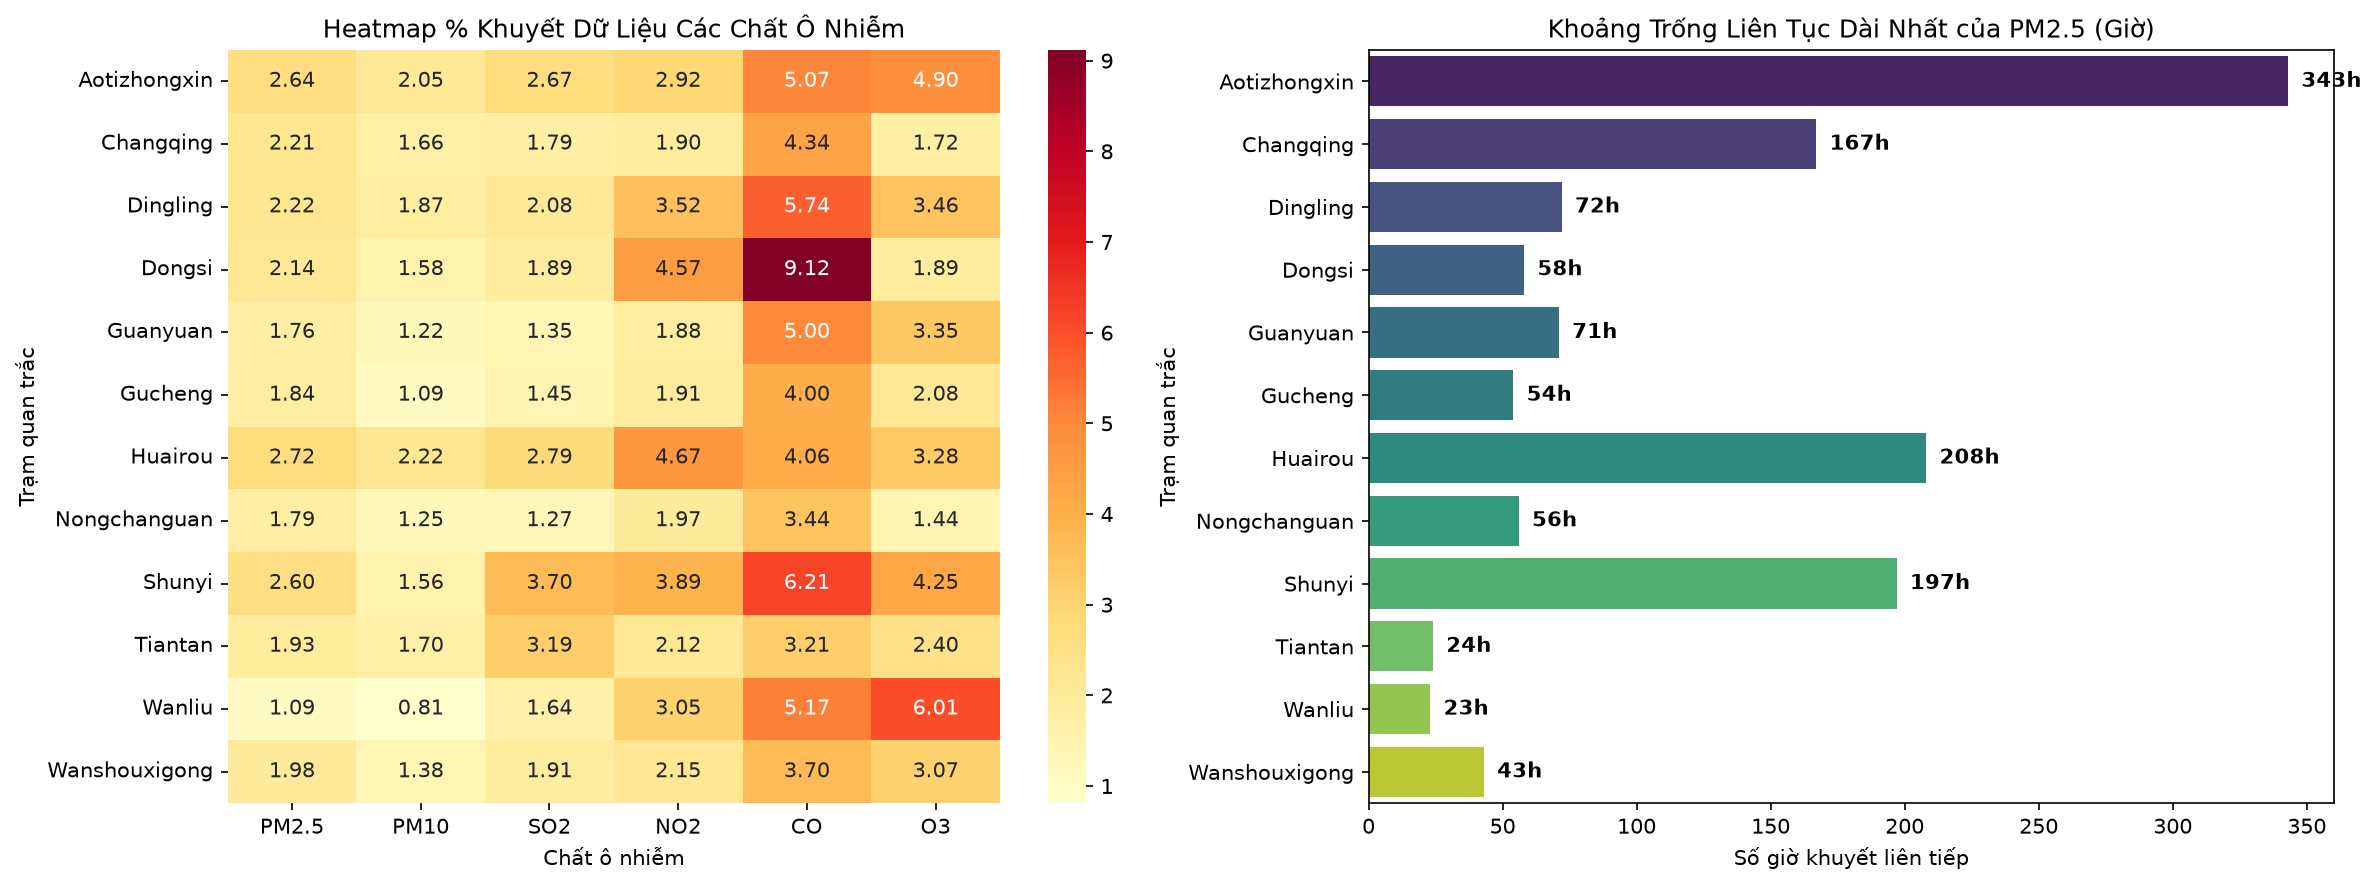

In [23]:
def longest_consecutive_gap(series):
    mask = series.isna().astype(int)
    if mask.sum() == 0:
        return 0
    groups = (mask != mask.shift()).cumsum()
    return int(mask[mask == 1].groupby(groups[mask == 1]).transform("count").max())

missing_pct  = {}
longest_gaps = {}
for st, df in stations_raw.items():
    pct = {}
    for col in POLLUTANTS:
        pct[col] = df[col].isna().mean()*100 if col in df.columns else 100.0
    missing_pct[st]  = pct
    longest_gaps[st] = longest_consecutive_gap(df["PM2.5"]) if "PM2.5" in df.columns else 0

missing_df = pd.DataFrame(missing_pct).T.sort_index()
gaps_df    = pd.Series(longest_gaps, name="Longest_Gap_PM25").sort_index()

print("% Thiếu:\n", missing_df.round(2).to_string())
print("\nKhoảng trống dài nhất PM2.5 (giờ):")
print(gaps_df.sort_values(ascending=False).to_string())

# --- Vẽ 2 Biểu Đồ ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Heatmap % thiếu
sns.heatmap(missing_df, annot=True, fmt=".2f", cmap="YlOrRd", cbar=True, ax=axes[0])
axes[0].set_title("Heatmap % Khuyết Dữ Liệu Các Chất Ô Nhiễm")
axes[0].set_xlabel("Chất ô nhiễm")
axes[0].set_ylabel("Trạm quan trắc")

# Biểu đồ 2: Bar chart khoảng trống PM2.5 dài nhất
sns.barplot(x=gaps_df.values, y=gaps_df.index, palette="viridis", ax=axes[1])
axes[1].set_title("Khoảng Trống Liên Tục Dài Nhất của PM2.5 (Giờ)")
axes[1].set_xlabel("Số giờ khuyết liên tiếp")
axes[1].set_ylabel("Trạm quan trắc")
for i, v in enumerate(gaps_df.values):
    axes[1].text(v + 5, i, f"{v}h", va='center', fontweight='bold')

plt.tight_layout()

# Để hiển thị biểu đồ trong môi trường lưu trữ Agg, ta lưu lại thành file ảnh và hiển thị bằng IPython.display
fig_path = "missing_and_gaps_analysis.png"
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close(fig)

from IPython.display import Image, display as ipy_display
ipy_display(Image(fig_path))

## Phần 1 — Chuẩn hóa dữ liệu

### Bước 1.1: Chuẩn hóa thời gian và tạo lưới giờ liên tục

Tạo `datetime` từ các cột `year`, `month`, `day`, `hour`; sắp xếp theo trạm và thời gian; loại bản ghi trùng; sau đó reindex từng trạm theo tần suất một giờ.

Các giờ bị thiếu hoàn toàn sẽ được thêm vào dưới dạng dòng có giá trị NaN. Việc này bảo đảm `shift()` và `rolling()` ở bước tạo feature hoạt động đúng theo thời gian, không bị lệch do thiếu dòng.

Đồng thời, các cột số được chuyển về kiểu numeric và giá trị âm không hợp lệ của pollutant được đổi thành NaN để xử lý thống nhất ở bước 1.2.


In [24]:
def clean_station_df(df):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]])
    df = df.sort_values(["station","datetime"]).drop_duplicates(subset=["station","datetime"])
    full_frames = []
    for st, g in df.groupby("station"):
        g = g.set_index("datetime").sort_index()
        full_idx = pd.date_range(g.index.min(), g.index.max(), freq="h")
        g = g.reindex(full_idx)
        g["station"] = st
        g.index.name = "datetime"
        full_frames.append(g)
    df = pd.concat(full_frames).reset_index()
    num_cols_all = ["PM2.5","PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","WSPM"]
    for c in num_cols_all:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    for c in ["PM2.5","PM10","SO2","NO2","CO","O3","RAIN","WSPM"]:
        if c in df.columns:
            df.loc[df[c] < 0, c] = np.nan
    df["year"]  = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["day"]   = df["datetime"].dt.day
    df["hour"]  = df["datetime"].dt.hour
    return df.drop(columns=["No"], errors="ignore")

print("Đang reindex lưới giờ...")
stations_clean = {}
for st, df in stations_raw.items():
    stations_clean[st] = clean_station_df(df)

df_all = pd.concat(stations_clean.values(), ignore_index=True)
row_counts_clean = {st: len(df) for st, df in stations_clean.items()}

for st in sorted(stations_clean.keys()):
    b, a = row_counts_raw.get(st,0), row_counts_clean[st]
    print(f"  {st:20s}: {b:>6,} → {a:>6,}  (+{a-b})")
print(f"\ndf_all: {df_all.shape[0]:,} dòng | {df_all.shape[1]} cột")

Đang reindex lưới giờ...
  Aotizhongxin        : 35,064 → 35,064  (+0)
  Changqing           : 35,064 → 35,064  (+0)
  Dingling            : 35,064 → 35,064  (+0)
  Dongsi              : 35,064 → 35,064  (+0)
  Guanyuan            : 35,064 → 35,064  (+0)
  Gucheng             : 35,064 → 35,064  (+0)
  Huairou             : 35,064 → 35,064  (+0)
  Nongchanguan        : 35,064 → 35,064  (+0)
  Shunyi              : 35,064 → 35,064  (+0)
  Tiantan             : 35,064 → 35,064  (+0)
  Wanliu              : 35,064 → 35,064  (+0)
  Wanshouxigong       : 35,064 → 35,064  (+0)

df_all: 420,768 dòng | 18 cột


### Bước 1.2: Xử lý giá trị thiếu theo ba tầng

Mỗi trạm được xử lý độc lập để tránh trộn dữ liệu giữa các địa điểm:

1. **Nội suy theo thời gian** cho khoảng thiếu ngắn, tối đa 3 giờ và chỉ nội suy bên trong chuỗi.
2. **Median theo tháng và giờ** cho các khoảng thiếu dài hơn, nhằm giữ lại quy luật mùa và quy luật trong ngày.
3. **Median của riêng trạm** làm phương án dự phòng khi nhóm tháng–giờ không đủ dữ liệu.

Riêng `RAIN` được điền bằng 0 theo giả định lượng mưa ở giờ thiếu thường là không đáng kể. `wd` được xử lý bằng forward-fill ngắn, sau đó dùng mode theo tháng–giờ và mode của trạm.

Trước khi điền, pipeline lưu các cờ `*_was_missing` để phân biệt dữ liệu quan sát gốc với giá trị được ước lượng. Các cờ này được dùng để đánh giá độ tin cậy của AQI và kiểm soát dữ liệu khi modeling.

Mục tiêu của bước này là không còn NaN ở các feature số bắt buộc, nhưng không che giấu nguồn gốc của các giá trị đã được điền.


Đang điền theo chiến lược 3 tầng và lưu cờ missing...
NaN còn lại: 0 NaN
Tổng NaN: 0
Đã lưu 12 cột cờ missing.


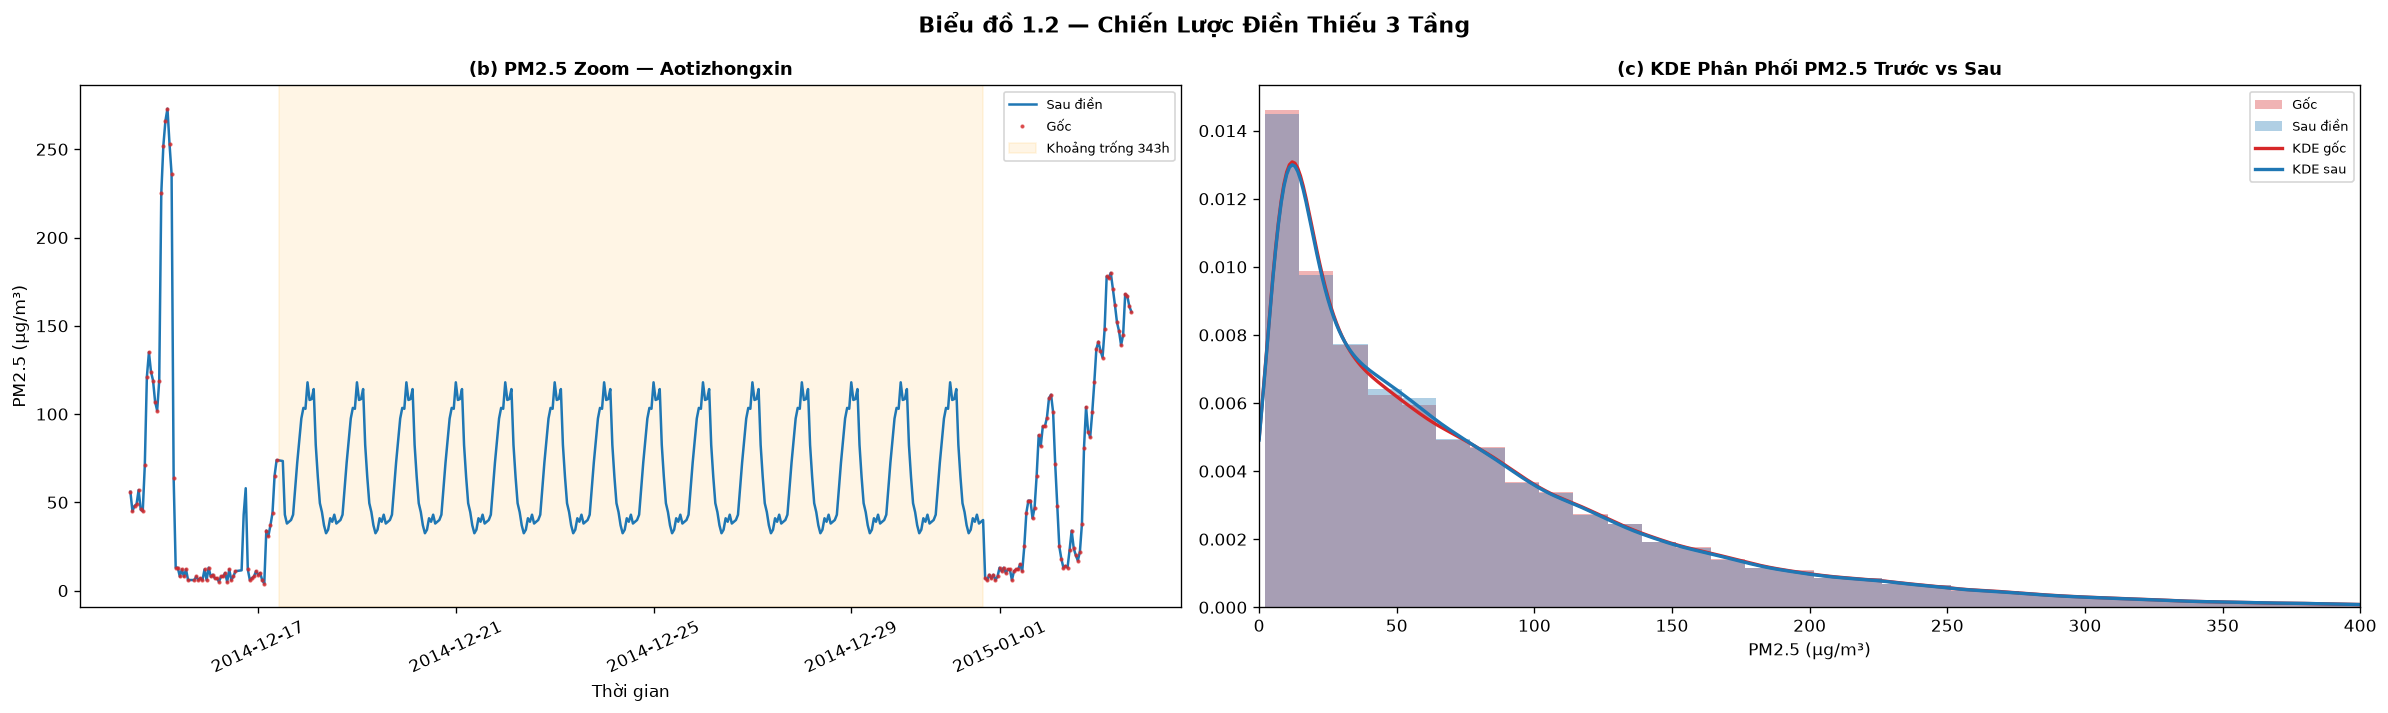

In [25]:
from scipy.stats import gaussian_kde
pct_before = {col: df_all[col].isna().mean() * 100 for col in POLLUTANTS}

worst_station = gaps_df.idxmax()
worst_gap = gaps_df.max()
ws_orig_series = stations_clean[worst_station].set_index("datetime")["PM2.5"]
is_null = ws_orig_series.isna()
null_grp = (is_null != is_null.shift()).cumsum()
if is_null.sum() > 0:
    blk_sizes = is_null[is_null].groupby(null_grp[is_null]).transform("count")
    max_blk = null_grp[is_null][blk_sizes == blk_sizes.max()].iloc[0]
    gap_idx = ws_orig_series.index[null_grp == max_blk]
    zoom_s = gap_idx[0] - pd.Timedelta(hours=72)
    zoom_e = gap_idx[-1] + pd.Timedelta(hours=72)
else:
    zoom_s = ws_orig_series.index[0]
    zoom_e = ws_orig_series.index[200]

pm25_goc = df_all.set_index(["station", "datetime"])["PM2.5"].copy()
tracked_cols = [c for c in NUM_COLS + ["wd"] if c in df_all.columns]
missing_flag_cols = [f"{c}_was_missing" for c in tracked_cols]

def impute_station(g):
    g = g.sort_values("datetime").copy()
    for col in tracked_cols:
        g[f"{col}_was_missing"] = g[col].isna().astype("int8")
    g = g.set_index("datetime")
    numeric_cols = [c for c in NUM_COLS if c in g.columns and c != "RAIN"]
    for col in numeric_cols:
        g[col] = g[col].interpolate(method="time", limit=3, limit_area="inside")
    g = g.reset_index()
    for col in numeric_cols:
        med_mh = g.groupby(["month", "hour"])[col].transform("median")
        g[col] = g[col].fillna(med_mh)
    for col in numeric_cols:
        g[col] = g[col].fillna(g[col].median())
    if "RAIN" in g.columns:
        g["RAIN"] = g["RAIN"].fillna(0.0)
    if "wd" in g.columns:
        g["wd"] = g["wd"].ffill(limit=3)
        mode_mh = g.groupby(["month", "hour"])["wd"].transform(
            lambda x: x.mode().iloc[0] if x.notna().any() else np.nan)
        g["wd"] = g["wd"].fillna(mode_mh)
        fallback_mode = g["wd"].mode().iloc[0] if g["wd"].notna().any() else "N"
        g["wd"] = g["wd"].fillna(fallback_mode)
    return g

print("Đang điền theo chiến lược 3 tầng và lưu cờ missing...")
_frames_imp = []
for _st in sorted(df_all["station"].unique()):
    _frames_imp.append(impute_station(df_all[df_all["station"] == _st].copy()))
df_all = pd.concat(_frames_imp, ignore_index=True)

missing_flags_after = [c for c in missing_flag_cols if c in df_all.columns]
missing_flags_lost = sorted(set(missing_flag_cols) - set(missing_flags_after))
if missing_flags_lost:
    raise RuntimeError(f"Mất cờ missing sau khi nối dữ liệu: {missing_flags_lost}")

pct_after = {col: df_all[col].isna().mean() * 100 for col in POLLUTANTS}
remaining = df_all[NUM_COLS].isna().sum()
print("NaN còn lại:", remaining[remaining > 0].to_dict() if remaining.sum() > 0 else "0 NaN")
print(f"Tổng NaN: {remaining.sum()}")
print(f"Đã lưu {len(missing_flags_after)} cột cờ missing.")

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
ws_clean = df_all[df_all["station"] == worst_station].set_index("datetime")["PM2.5"]
z_orig = ws_orig_series.loc[zoom_s:zoom_e]
z_clean = ws_clean.loc[zoom_s:zoom_e]
axes[0].plot(z_clean.index, z_clean.values, color="#1f77b4", linewidth=1.5, label="Sau điền", zorder=3)
axes[0].plot(z_orig.index, z_orig.values, ".", color="#d62728", markersize=3, label="Gốc", alpha=0.7, zorder=4)
axes[0].axvspan(gap_idx[0], gap_idx[-1], alpha=0.1, color="orange", label=f"Khoảng trống {worst_gap}h")
axes[0].set_title(f"(b) PM2.5 Zoom — {worst_station}", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Thời gian"); axes[0].set_ylabel("PM2.5 (μg/m³)")
axes[0].legend(fontsize=8); axes[0].tick_params(axis="x", rotation=25)

pm25_o = pm25_goc.dropna().values
pm25_c = df_all["PM2.5"].dropna().values
axes[1].hist(pm25_o, bins=80, density=True, alpha=0.35, color="#d62728", label="Gốc")
axes[1].hist(pm25_c, bins=80, density=True, alpha=0.35, color="#1f77b4", label="Sau điền")
for vals, color, label in [(pm25_o, "#d62728", "KDE gốc"), (pm25_c, "#1f77b4", "KDE sau")]:
    kde = gaussian_kde(np.clip(vals, 0, 500))
    xs = np.linspace(0, 500, 500)
    axes[1].plot(xs, kde(xs), color=color, linewidth=2, label=label)
axes[1].set_xlim(0, 400); axes[1].set_xlabel("PM2.5 (μg/m³)")
axes[1].set_title("(c) KDE Phân Phối PM2.5 Trước vs Sau", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8)
plt.suptitle("Biểu đồ 1.2 — Chiến Lược Điền Thiếu 3 Tầng", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_1_2_imputation.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

from IPython.display import Image, display as ipy_display
ipy_display(Image("fig_1_2_imputation.png"))


### Bước 1.3: Tính AQI theo giờ và đánh dấu độ tin cậy

Tính IAQI cho từng pollutant bằng nội suy tuyến tính giữa các breakpoint theo giờ, sau đó lấy giá trị lớn nhất làm AQI của mỗi dòng:

$$AQI_t = \max(IAQI_{PM2.5,t}, IAQI_{PM10,t}, IAQI_{SO2,t}, IAQI_{NO2,t}, IAQI_{CO,t}, IAQI_{O3,t})$$

AQI được tính trên `df_all` sau khi imputation. Vì vậy, pipeline đồng thời tạo các trường kiểm soát:

- `AQI_imputed_count`: số pollutant dùng giá trị đã được điền.
- `AQI_partial`: bằng 1 nếu AQI phụ thuộc ít nhất một pollutant được điền.
- `AQI_all_pollutants_were_missing`: bằng 1 nếu cả sáu pollutant tại thời điểm đó đều bị thiếu ban đầu.
- `AQI_Level`: phân loại AQI thành sáu mức từ tốt đến nguy hại.

Các cờ này không thay thế AQI; chúng giúp người dùng lọc hoặc phân tích độ tin cậy của AQI trong các bước EDA và modeling.


In [26]:
# Bảng breakpoint nồng độ 1 giờ (HJ 633-2012).
# CO trong dữ liệu đã ở đơn vị ug/m3 nên dùng trực tiếp breakpoint tương ứng.
breakpoints_hourly = {
    "PM2.5": [0, 35, 75, 115, 150, 250, 350, 500, 99999],
    "PM10": [0, 50, 150, 250, 350, 420, 500, 600, 99999],
    "SO2": [0, 150, 500, 650, 800, 99999],
    "NO2": [0, 100, 200, 700, 1200, 2340, 3090, 3840, 99999],
    "CO": [0, 5000, 10000, 35000, 60000, 90000, 120000, 150000, 999999],
    "O3": [0, 160, 200, 300, 400, 800, 1000, 1200, 99999]
}

iaqi_levels = {
    "PM2.5": [0, 50, 100, 150, 200, 300, 400, 500, 500],
    "PM10": [0, 50, 100, 150, 200, 300, 400, 500, 500],
    "SO2": [0, 50, 100, 150, 200, 500],
    "NO2": [0, 50, 100, 150, 200, 300, 400, 500, 500],
    "CO": [0, 50, 100, 150, 200, 300, 400, 500, 500],
    "O3": [0, 50, 100, 150, 200, 300, 400, 500, 500]
}

POLLUTANTS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]

def calculate_iaqi_hourly(cp, pollutant):
    if pd.isna(cp) or cp < 0:
        return np.nan
    bp_c = breakpoints_hourly[pollutant]
    iaqi_b = iaqi_levels[pollutant]
    for i in range(len(bp_c) - 1):
        if bp_c[i] <= cp <= bp_c[i + 1]:
            bplo, bphi = bp_c[i], bp_c[i + 1]
            iaqilo, iaqihi = iaqi_b[i], iaqi_b[i + 1]
            if bphi == bplo:
                return iaqihi
            return np.ceil((iaqihi - iaqilo) / (bphi - bplo) * (cp - bplo) + iaqilo)
    return 500

print("Đang tính toán IAQI, AQI và AQI_Level trên df_all đã impute...")
iaqi_cols = []
for pollutant in POLLUTANTS:
    col_name = f"IAQI_{pollutant}"
    df_all[col_name] = df_all[pollutant].apply(
        lambda value: calculate_iaqi_hourly(value, pollutant)
    )
    iaqi_cols.append(col_name)

df_all["AQI"] = df_all[iaqi_cols].max(axis=1)
df_all["AQI_Level"] = pd.cut(
    df_all["AQI"], bins=[-1, 50, 100, 150, 200, 300, np.inf],
    labels=[1, 2, 3, 4, 5, 6]
)

pollutant_missing_flags = [f"{pollutant}_was_missing" for pollutant in POLLUTANTS]
df_all["AQI_imputed_count"] = df_all[pollutant_missing_flags].sum(axis=1).astype("int8")
df_all["AQI_partial"] = (df_all["AQI_imputed_count"] > 0).astype("int8")
df_all["AQI_all_pollutants_were_missing"] = (
    df_all["AQI_imputed_count"] == len(POLLUTANTS)
).astype("int8")

print("\nPhân phối AQI_Level (1-6) theo giờ:")
print(df_all["AQI_Level"].value_counts().sort_index())
print("\nAQI có ít nhất một pollutant được impute:", int(df_all["AQI_partial"].sum()))
print("AQI có toàn bộ pollutant được impute:", int(df_all["AQI_all_pollutants_were_missing"].sum()))


Đang tính toán IAQI, AQI và AQI_Level trên df_all đã impute...

Phân phối AQI_Level (1-6) theo giờ:
AQI_Level
1    121583
2    121942
3     75662
4     36783
5     45071
6     19727
Name: count, dtype: int64

AQI có ít nhất một pollutant được impute: 36788
AQI có toàn bộ pollutant được impute: 4969


In [27]:


try:
    df_all.to_parquet(OUT_FILE, index=False)
    print(f" Xuất file thành công! Đường dẫn file: {os.path.abspath(OUT_FILE)}")
    print(f"Kích thước file: {os.path.getsize(OUT_FILE) / (1024 * 1024):.2f} MB")
except Exception as e:
    print(f"Đã xảy ra lỗi khi xuất file: {e}")

 Xuất file thành công! Đường dẫn file: c:\Users\linhk\Documents\essays\data\Data_processing\data_insights_clean\data\data_cleaned_all_stations.parquet
Kích thước file: 9.21 MB


## Phần 2 — Xuất dữ liệu sạch

Ghi `df_all` ra `data_cleaned_all_stations.parquet` sau khi hoàn tất imputation và tính AQI. File này là đầu vào cho `eda_processing.ipynb` và `Model_prepare.ipynb`.


In [28]:
display(df_all.head())

,datetime,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,DEWP_was_missing,RAIN_was_missing,WSPM_was_missing,wd_was_missing,IAQI_PM2.5,IAQI_PM10,IAQI_SO2,IAQI_NO2,IAQI_CO,IAQI_O3,AQI,AQI_Level,AQI_imputed_count,AQI_partial,AQI_all_pollutants_were_missing
0,2013-03-01 00:00:00,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,...,0,0,0,0,6.0,4.0,2.0,4.0,3.0,25.0,25.0,1,0,0,0
1,2013-03-01 01:00:00,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,...,0,0,0,0,12.0,8.0,2.0,4.0,3.0,25.0,25.0,1,0,0,0
2,2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,...,0,0,0,0,10.0,7.0,2.0,5.0,3.0,23.0,23.0,1,0,0,0
3,2013-03-01 03:00:00,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,...,0,0,0,0,9.0,6.0,4.0,6.0,3.0,23.0,23.0,1,0,0,0
4,2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,...,0,0,0,0,5.0,3.0,4.0,6.0,3.0,23.0,23.0,1,0,0,0


In [29]:
# Kiểm tra NaN và chất lượng giá trị được ước lượng sau khi làm sạch
required_cols = NUM_COLS + ["AQI", "AQI_Level"]
missing_required = [c for c in required_cols if c not in df_all.columns]
if missing_required:
    raise ValueError(f"Thiếu cột bắt buộc: {missing_required}")

nan_by_column = df_all[required_cols].isna().sum().sort_values(ascending=False)
nan_by_station = df_all.groupby("station")[required_cols].apply(
    lambda group: int(group.isna().sum().sum())
)
total_nan = int(nan_by_column.sum())
flag_cols = [c for c in df_all.columns if c.endswith("_was_missing")]

print("Kiểm tra dữ liệu sau Data_clean:")
print(f"Tổng NaN ở cột bắt buộc: {total_nan:,}")
print("\nNaN theo cột:")
print(nan_by_column[nan_by_column > 0].to_string() if total_nan else "Không còn NaN")
print("\nTổng NaN theo trạm:")
print(nan_by_station.to_string())
print(f"\nSố cột cờ missing được lưu: {len(flag_cols)}")
print(f"Số dòng AQI có pollutant được impute: {int(df_all['AQI_partial'].sum()):,}")
print(f"Số dòng AQI có toàn bộ pollutant được impute: {int(df_all['AQI_all_pollutants_were_missing'].sum()):,}")

if total_nan:
    raise ValueError("Cột bắt buộc vẫn còn NaN; dừng trước khi export/modeling.")

print("\nKết luận: Không còn NaN ở cột bắt buộc.")
print("Lưu ý: dùng các cột *_was_missing và AQI_partial để lọc hoặc kiểm soát độ tin cậy khi modeling.")


Kiểm tra dữ liệu sau Data_clean:
Tổng NaN ở cột bắt buộc: 0

NaN theo cột:
Không còn NaN

Tổng NaN theo trạm:
station
Aotizhongxin     0
Changping        0
Dingling         0
Dongsi           0
Guanyuan         0
Gucheng          0
Huairou          0
Nongzhanguan     0
Shunyi           0
Tiantan          0
Wanliu           0
Wanshouxigong    0

Số cột cờ missing được lưu: 12
Số dòng AQI có pollutant được impute: 36,788
Số dòng AQI có toàn bộ pollutant được impute: 4,969

Kết luận: Không còn NaN ở cột bắt buộc.
Lưu ý: dùng các cột *_was_missing và AQI_partial để lọc hoặc kiểm soát độ tin cậy khi modeling.
